Proyecto Procesamiento de Datos - Entrega 1

In [1]:
pip install pyspark

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import ScalarFormatter
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [3]:
spark = SparkSession.builder.appName("proyecto_1").getOrCreate()

In [4]:
icfes=spark.read.csv(r"C:\Users\Windows\Downloads\Resultados_únicos_Saber_11_20260403.csv", header=True, inferSchema=True)
internet=spark.read.csv(r"C:\Users\Windows\Downloads\Internet_Fijo_Accesos_por_tecnología_y_segmento_20260403.csv", header=True, inferSchema=True)

In [5]:
import os
os.makedirs("outputs_eda", exist_ok=True)
os.makedirs("outputs_eda/plots", exist_ok=True)
os.makedirs("outputs_eda/tables", exist_ok=True)

In [6]:
icfes.printSchema()

root
 |-- PERIODO: integer (nullable = true)
 |-- ESTU_TIPODOCUMENTO: string (nullable = true)
 |-- ESTU_CONSECUTIVO: string (nullable = true)
 |-- COLE_AREA_UBICACION: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- COLE_CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: long (nullable = true)
 |-- COLE_COD_DANE_SEDE: long (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: integer (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: integer (nullable = true)
 |-- COLE_CODIGO_ICFES: integer (nullable = true)
 |-- COLE_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- COLE_JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_NATURALEZA: string (nullable = true)
 |-- COLE_NOMBRE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: string (nullable = true)
 |

In [7]:
schema_icfes = pd.DataFrame(
    [(f.name, str(f.dataType), f.nullable) for f in icfes.schema.fields],
    columns=["columna", "tipo", "nullable"]
)
schema_icfes.to_csv("outputs_eda/tables/schema_icfes.csv", index=False)

In [8]:
pdf = (
    icfes.groupBy("PERIODO")
    .count()
    .orderBy("PERIODO")
    .toPandas()
)

plt.figure(figsize=(12,6))
plt.bar(pdf["PERIODO"].astype(str), pdf["count"])

ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=90)
plt.title("Cantidad de registros ICFES por periodo")
plt.xlabel("Periodo")
plt.ylabel("Número de registros")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g1_icfes_registros_por_periodo.png", dpi=300)
plt.close()

In [9]:
internet.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- PROVEEDOR: string (nullable = true)
 |-- COD_DEPARTAMENTO: integer (nullable = true)
 |-- DEPARTAMENTO: string (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- MUNICIPIO: string (nullable = true)
 |-- SEGMENTO: string (nullable = true)
 |-- TECNOLOGIA: string (nullable = true)
 |-- VELOCIDAD_BAJADA: string (nullable = true)
 |-- VELOCIDAD_SUBIDA: string (nullable = true)
 |-- No DE ACCESOS: integer (nullable = true)



In [10]:
schema_internet = pd.DataFrame(
    [(f.name, str(f.dataType), f.nullable) for f in internet.schema.fields],
    columns=["columna", "tipo", "nullable"]
)
schema_internet.to_csv("outputs_eda/tables/schema_internet.csv", index=False)

In [11]:
icfes.summary().show()

+-------+------------------+------------------+------------------+-------------------+-------------+---------------+-----------------+-----------------------------+--------------------+------------------------+------------------------+------------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+------------------+------------------+------------------------+------------------+----

In [12]:
internet.summary().show()

+-------+------------------+------------------+--------------------+------------------+------------+------------------+---------+--------------------+----------+----------------+----------------+-----------------+
|summary|               AÑO|         TRIMESTRE|           PROVEEDOR|  COD_DEPARTAMENTO|DEPARTAMENTO|     COD_MUNICIPIO|MUNICIPIO|            SEGMENTO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|    No DE ACCESOS|
+-------+------------------+------------------+--------------------+------------------+------------+------------------+---------+--------------------+----------+----------------+----------------+-----------------+
|  count|           2795052|           2795052|             2795052|           2795047|     2795052|           2795042|  2795052|             2795052|   2795052|         2795052|         2795052|          2795052|
|   mean|2020.9017853692883|2.4440740279608395|                NULL| 37.26432149441494|        NULL| 37581.22693433587|     NULL|               

In [13]:
def missing_table_spark(df):
    total = df.count()
    exprs = [
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]
    row = df.select(exprs).toPandas().T.reset_index()
    row.columns = ["columna", "nulos"]
    row["total_registros"] = total
    row["pct_nulos"] = (row["nulos"] / total) * 100
    return row.sort_values("pct_nulos", ascending=False)

In [14]:
missing_icfes = missing_table_spark(icfes)
missing_icfes.to_csv("outputs_eda/tables/missing_icfes.csv", index=False)

missing_internet = missing_table_spark(internet)
missing_internet.to_csv("outputs_eda/tables/missing_internet.csv", index=False)

In [15]:
internet.select(F.col("SEGMENTO")).distinct().show(truncate=False)

+-------------------------------+
|SEGMENTO                       |
+-------------------------------+
|RESIDENCIAL - ESTRATO 1        |
|CORPORATIVO                    |
|RESIDENCIAL - ESTRATO 6        |
|RESIDENCIAL - ESTRATO 5        |
|RESIDENCIAL - ESTRATO 4        |
|RESIDENCIAL - ESTRATO 3        |
|RESIDENCIAL - ESTRATO 2        |
|SIN ESTRATIFICAR               |
|USO PROPIO INTERNO DEL OPERADOR|
+-------------------------------+



In [16]:
internet.groupby(F.col("TECNOLOGIA")).count().show(truncate=False)

+----------------------------------------------------+------+
|TECNOLOGIA                                          |count |
+----------------------------------------------------+------+
|OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX)             |156455|
|CABLE                                               |639283|
|SATELITAL                                           |174319|
|WIMAX                                               |15981 |
|FIBER TO THE HOME (FTTH)                            |630091|
|HYBRID FIBER COAXIAL (HFC)                          |212051|
|FIBER TO THE ANTENNA (FTTA)                         |2594  |
|XDSL                                                |510367|
|OTRAS TECNOLOGÍAS INALÁMBRICAS                      |280690|
|FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)|20035 |
|WIFI                                                |110824|
|FIBER TO THE NODE (FTTN)                            |1888  |
|OTRAS TECNOLOGÍAS FIJAS                             |7033  |
|FIBER T

In [17]:
internet_anio_counts = (
    internet.groupBy("AÑO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy("AÑO")
    .toPandas()
)
internet_anio_counts.to_csv("outputs_eda/tables/internet_anio_counts.csv", index=False)

In [18]:
internet_segmento = (
    internet.groupBy("SEGMENTO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .toPandas()
)
internet_segmento.to_csv("outputs_eda/tables/internet_segmento.csv", index=False)

In [19]:
internet_tecnologia = (
    internet.groupBy("TECNOLOGIA")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .toPandas()
)
internet_tecnologia.to_csv("outputs_eda/tables/internet_tecnologia.csv", index=False)

In [20]:
internet_anio_counts = (
    internet.groupBy("AÑO")
    .agg(F.sum(F.col("No DE ACCESOS")).alias("total_accesos"))
    .orderBy("AÑO")
)

# 2. Pasar a pandas
pdf = internet_anio_counts.toPandas().copy()

# 3. Graficar
plt.figure(figsize=(10,6))
plt.plot(pdf["AÑO"], pdf["total_accesos"], marker="o")

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.title("Evolución del total de accesos a internet fijo por año")
plt.xlabel("Año")
plt.ylabel("Total de accesos")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g3_internet_accesos_por_anio.png", dpi=300)
plt.close()

In [21]:
internet = internet.select("AÑO","TRIMESTRE","COD_MUNICIPIO","SEGMENTO","TECNOLOGIA","VELOCIDAD_BAJADA","VELOCIDAD_SUBIDA","No DE ACCESOS")

In [22]:
internet = internet.withColumn(
    "TIPO_SEGMENTO",
    F.when(F.col("SEGMENTO").startswith("RESIDENCIAL"), "RESIDENCIAL")
     .when(F.col("SEGMENTO") == "CORPORATIVO", "CORPORATIVO")
     .when(F.col("SEGMENTO") == "SIN ESTRATIFICAR", "SIN_ESTRATIFICAR")
     .when(F.col("SEGMENTO") == "USO PROPIO INTERNO DEL OPERADOR", "OPERADOR")
     .otherwise("OTRO")
).withColumn(
    "ESTRATO_RESIDENCIAL",
    F.when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 1", 1)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 2", 2)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 3", 3)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 4", 4)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 5", 5)
     .when(F.col("SEGMENTO") == "RESIDENCIAL - ESTRATO 6", 6)
     .otherwise(None)
     .cast("int")
).withColumn(
    "ACCESOS_RESIDENCIAL",
    F.when(F.col("TIPO_SEGMENTO") == "RESIDENCIAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_CORPORATIVO",
    F.when(F.col("TIPO_SEGMENTO") == "CORPORATIVO", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_SIN_ESTRATIFICAR",
    F.when(F.col("TIPO_SEGMENTO") == "SIN_ESTRATIFICAR", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_OPERADOR",
    F.when(F.col("TIPO_SEGMENTO") == "OPERADOR", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ESTRATO_X_ACCESOS",
    F.when(
        F.col("ESTRATO_RESIDENCIAL").isNotNull(),
        F.col("ESTRATO_RESIDENCIAL") * F.col("No DE ACCESOS")
    ).otherwise(0)
)

internet = internet.withColumn(
    "TEC_FAMILIA",
    F.when(
        (F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS DE FIBRA (ANTES FTTX)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE HOME (FTTH)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE ANTENNA (FTTA)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE NODE (FTTN)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE CABINET (FTTC)") |
        (F.col("TECNOLOGIA") == "FIBER TO THE PREMISES"),
        "FIBRA"
    ).when(
        (F.col("TECNOLOGIA") == "CABLE") |
        (F.col("TECNOLOGIA") == "HYBRID FIBER COAXIAL (HFC)"),
        "CABLE_COAXIAL"
    ).when(
        F.col("TECNOLOGIA") == "XDSL",
        "XDSL"
    ).when(
        F.col("TECNOLOGIA") == "SATELITAL",
        "SATELITAL"
    ).when(
        (F.col("TECNOLOGIA") == "WIMAX") |
        (F.col("TECNOLOGIA") == "WIFI") |
        (F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS INALÁMBRICAS"),
        "INALAMBRICA_FIJA"
    ).when(
        F.col("TECNOLOGIA") == "OTRAS TECNOLOGÍAS FIJAS",
        "OTRAS_FIJAS"
    ).when(
        F.col("TECNOLOGIA") == "NA (NO APLICA)",
        "NO_APLICA"
    ).otherwise("OTRO")
)

internet = internet.withColumn(
    "ACCESOS_FIBRA",
    F.when(F.col("TEC_FAMILIA") == "FIBRA", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_CABLE",
    F.when(F.col("TEC_FAMILIA") == "CABLE_COAXIAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_XDSL",
    F.when(F.col("TEC_FAMILIA") == "XDSL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_SATELITAL",
    F.when(F.col("TEC_FAMILIA") == "SATELITAL", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_INALAMBRICA",
    F.when(F.col("TEC_FAMILIA") == "INALAMBRICA_FIJA", F.col("No DE ACCESOS")).otherwise(0)
).withColumn(
    "ACCESOS_OTRAS_FIJAS",
    F.when(F.col("TEC_FAMILIA") == "OTRAS_FIJAS", F.col("No DE ACCESOS")).otherwise(0)
)

In [23]:
internet = internet.select("AÑO","TRIMESTRE","COD_MUNICIPIO","TECNOLOGIA","VELOCIDAD_BAJADA","VELOCIDAD_SUBIDA","No DE ACCESOS","TIPO_SEGMENTO","ESTRATO_RESIDENCIAL","ACCESOS_RESIDENCIAL","ACCESOS_CORPORATIVO","ACCESOS_SIN_ESTRATIFICAR","ACCESOS_OPERADOR","ESTRATO_X_ACCESOS","TEC_FAMILIA","ACCESOS_FIBRA","ACCESOS_CABLE","ACCESOS_XDSL","ACCESOS_SATELITAL","ACCESOS_INALAMBRICA","ACCESOS_OTRAS_FIJAS")
internet.show(5)

+----+---------+-------------+----------+----------------+----------------+-------------+-------------+-------------------+-------------------+-------------------+------------------------+----------------+-----------------+----------------+-------------+-------------+------------+-----------------+-------------------+-------------------+
| AÑO|TRIMESTRE|COD_MUNICIPIO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|No DE ACCESOS|TIPO_SEGMENTO|ESTRATO_RESIDENCIAL|ACCESOS_RESIDENCIAL|ACCESOS_CORPORATIVO|ACCESOS_SIN_ESTRATIFICAR|ACCESOS_OPERADOR|ESTRATO_X_ACCESOS|     TEC_FAMILIA|ACCESOS_FIBRA|ACCESOS_CABLE|ACCESOS_XDSL|ACCESOS_SATELITAL|ACCESOS_INALAMBRICA|ACCESOS_OTRAS_FIJAS|
+----+---------+-------------+----------+----------------+----------------+-------------+-------------+-------------------+-------------------+-------------------+------------------------+----------------+-----------------+----------------+-------------+-------------+------------+-----------------+-------------------+-

In [24]:
internet = internet.dropna(subset=["COD_MUNICIPIO"])

In [25]:
internet = internet.withColumn(
    "VELOCIDAD_BAJADA_NUM",
    F.regexp_replace(F.col("VELOCIDAD_BAJADA"), ",", ".").cast("double")
).withColumn(
    "VELOCIDAD_SUBIDA_NUM",
    F.regexp_replace(F.col("VELOCIDAD_SUBIDA"), ",", ".").cast("double")
)

In [27]:
internet = internet.withColumn(
    "BAJADA_X_ACCESOS",
    F.col("VELOCIDAD_BAJADA_NUM") * F.col("No DE ACCESOS")
).withColumn(
    "SUBIDA_X_ACCESOS",
    F.col("VELOCIDAD_SUBIDA_NUM") * F.col("No DE ACCESOS")
)

In [28]:
internet.summary().show()

+-------+------------------+------------------+------------------+----------+----------------+----------------+-----------------+----------------+-------------------+-------------------+-------------------+------------------------+-------------------+------------------+-------------+------------------+-----------------+------------------+-------------------+-------------------+-------------------+--------------------+--------------------+------------------+-----------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|TECNOLOGIA|VELOCIDAD_BAJADA|VELOCIDAD_SUBIDA|    No DE ACCESOS|   TIPO_SEGMENTO|ESTRATO_RESIDENCIAL|ACCESOS_RESIDENCIAL|ACCESOS_CORPORATIVO|ACCESOS_SIN_ESTRATIFICAR|   ACCESOS_OPERADOR| ESTRATO_X_ACCESOS|  TEC_FAMILIA|     ACCESOS_FIBRA|    ACCESOS_CABLE|      ACCESOS_XDSL|  ACCESOS_SATELITAL|ACCESOS_INALAMBRICA|ACCESOS_OTRAS_FIJAS|VELOCIDAD_BAJADA_NUM|VELOCIDAD_SUBIDA_NUM|  BAJADA_X_ACCESOS| SUBIDA_X_ACCESOS|
+-------+------------------+------------

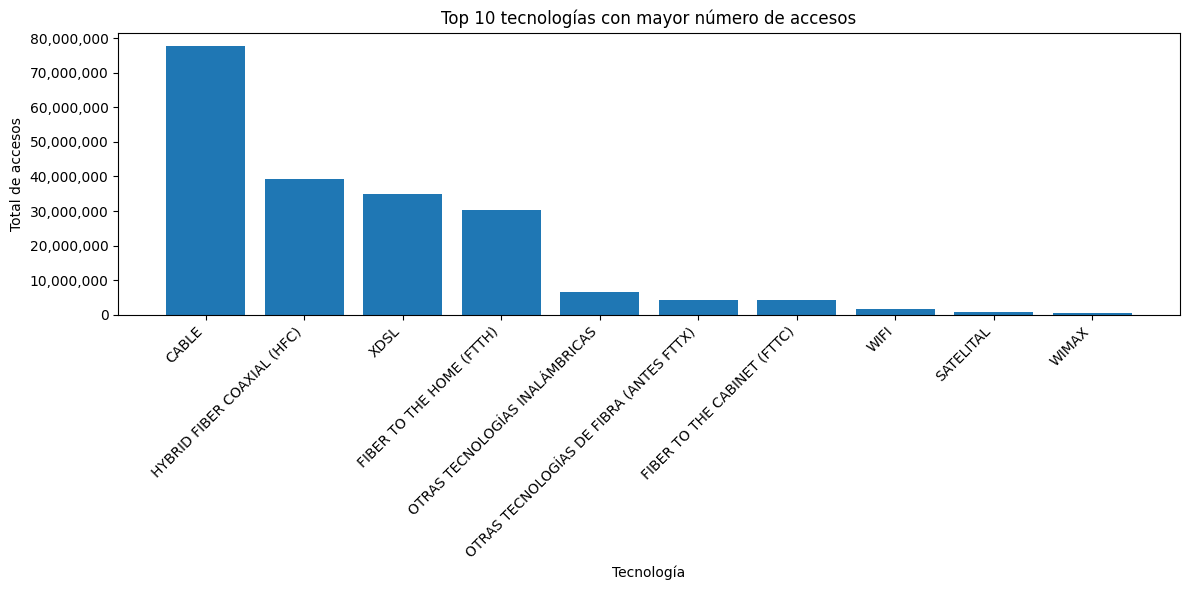

In [29]:
internet_tecnologia_pd = (
    internet.groupBy("TECNOLOGIA")
    .agg(F.sum("No DE ACCESOS").alias("total_accesos"))
    .orderBy(F.desc("total_accesos"))
    .limit(10)
    .toPandas()
)

# Guardar tabla
internet_tecnologia_pd.to_csv(
    "outputs_eda/tables/internet_tecnologia_top10.csv",
    index=False
)

# Graficar
plt.figure(figsize=(12,6))
plt.bar(internet_tecnologia_pd["TECNOLOGIA"], internet_tecnologia_pd["total_accesos"])

ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45, ha="right")
plt.title("Top 10 tecnologías con mayor número de accesos")
plt.xlabel("Tecnología")
plt.ylabel("Total de accesos")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g4_composicion_tecnologica_top10.png", dpi=300)
plt.show()
plt.close()

In [30]:
# Resumen por municipio y periodo
internet_municipios = internet.groupBy(
    "AÑO",
    "TRIMESTRE",
    "COD_MUNICIPIO"
).agg(
    F.sum("No DE ACCESOS").alias("TOTAL_ACCESOS"),

    # Segmento
    F.sum("ACCESOS_RESIDENCIAL").alias("TOTAL_ACCESOS_RESIDENCIAL"),
    F.sum("ACCESOS_CORPORATIVO").alias("TOTAL_ACCESOS_CORPORATIVO"),
    F.sum("ACCESOS_SIN_ESTRATIFICAR").alias("TOTAL_ACCESOS_SIN_ESTRATIFICAR"),
    F.sum("ACCESOS_OPERADOR").alias("TOTAL_ACCESOS_OPERADOR"),

    # Tecnología
    F.sum("ACCESOS_FIBRA").alias("TOTAL_ACCESOS_FIBRA"),
    F.sum("ACCESOS_CABLE").alias("TOTAL_ACCESOS_CABLE"),
    F.sum("ACCESOS_XDSL").alias("TOTAL_ACCESOS_XDSL"),
    F.sum("ACCESOS_SATELITAL").alias("TOTAL_ACCESOS_SATELITAL"),
    F.sum("ACCESOS_INALAMBRICA").alias("TOTAL_ACCESOS_INALAMBRICA"),
    F.sum("ACCESOS_OTRAS_FIJAS").alias("TOTAL_ACCESOS_OTRAS_FIJAS"),

    # Estrato residencial ponderado
    F.sum("ESTRATO_X_ACCESOS").alias("SUM_ESTRATO_X_ACCESOS"),

    # Velocidades ponderadas
    F.sum("BAJADA_X_ACCESOS").alias("SUM_BAJADA_X_ACCESOS"),
    F.sum("SUBIDA_X_ACCESOS").alias("SUM_SUBIDA_X_ACCESOS")
)

# Métricas derivadas
internet_municipios = internet_municipios.withColumn(
    "ESTRATO_PROMEDIO_RESIDENCIAL",
    F.when(
        F.col("TOTAL_ACCESOS_RESIDENCIAL") > 0,
        F.col("SUM_ESTRATO_X_ACCESOS") / F.col("TOTAL_ACCESOS_RESIDENCIAL")
    )
).withColumn(
    "VEL_BAJADA_PROMEDIO",
    F.when(
        F.col("TOTAL_ACCESOS") > 0,
        F.col("SUM_BAJADA_X_ACCESOS") / F.col("TOTAL_ACCESOS")
    )
).withColumn(
    "VEL_SUBIDA_PROMEDIO",
    F.when(
        F.col("TOTAL_ACCESOS") > 0,
        F.col("SUM_SUBIDA_X_ACCESOS") / F.col("TOTAL_ACCESOS")
    )
).withColumn(
    "PROP_RESIDENCIAL",
    F.col("TOTAL_ACCESOS_RESIDENCIAL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_CORPORATIVO",
    F.col("TOTAL_ACCESOS_CORPORATIVO") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_SIN_ESTRATIFICAR",
    F.col("TOTAL_ACCESOS_SIN_ESTRATIFICAR") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_OPERADOR",
    F.col("TOTAL_ACCESOS_OPERADOR") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_FIBRA",
    F.col("TOTAL_ACCESOS_FIBRA") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_CABLE",
    F.col("TOTAL_ACCESOS_CABLE") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_XDSL",
    F.col("TOTAL_ACCESOS_XDSL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_SATELITAL",
    F.col("TOTAL_ACCESOS_SATELITAL") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_INALAMBRICA",
    F.col("TOTAL_ACCESOS_INALAMBRICA") / F.col("TOTAL_ACCESOS")
).withColumn(
    "PROP_OTRAS_FIJAS",
    F.col("TOTAL_ACCESOS_OTRAS_FIJAS") / F.col("TOTAL_ACCESOS")
).drop(
    "SUM_ESTRATO_X_ACCESOS",
    "SUM_BAJADA_X_ACCESOS",
    "SUM_SUBIDA_X_ACCESOS"
)

In [31]:
internet_municipios.show(5, truncate=False)

+----+---------+-------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+-------------+-------------------+-------------------+------------------+---------------------+--------------------+----------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ACCESOS|TOTAL_ACCESOS_RESIDENCIAL|TOTAL_ACCESOS_CORPORATIVO|TOTAL_ACCESOS_SIN_ESTRATIFICAR|TOTAL_ACCESOS_OPERADOR|TOTAL_ACCESOS_FIBRA|TOTAL_ACCESOS_CABLE|TOTAL_ACCESOS_XDSL|TOTAL_ACCESOS_SATELITAL|TOTAL_ACCESOS_INALAMBRICA|TOTAL_ACCESOS_OTRAS_FIJAS|ESTRATO_PROMEDIO_RESIDENCIAL|VEL_BAJADA_PROMEDIO|VEL_SUBIDA_PROMEDIO|PROP_RESIDENCIAL  |PROP_CORPORATIVO   |PROP_SIN_ESTRATIFICAR|PROP_OPERADOR|PROP_FIBRA         |PR

In [32]:
internet_municipios.printSchema()

root
 |-- AÑO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- COD_MUNICIPIO: integer (nullable = true)
 |-- TOTAL_ACCESOS: long (nullable = true)
 |-- TOTAL_ACCESOS_RESIDENCIAL: long (nullable = true)
 |-- TOTAL_ACCESOS_CORPORATIVO: long (nullable = true)
 |-- TOTAL_ACCESOS_SIN_ESTRATIFICAR: long (nullable = true)
 |-- TOTAL_ACCESOS_OPERADOR: long (nullable = true)
 |-- TOTAL_ACCESOS_FIBRA: long (nullable = true)
 |-- TOTAL_ACCESOS_CABLE: long (nullable = true)
 |-- TOTAL_ACCESOS_XDSL: long (nullable = true)
 |-- TOTAL_ACCESOS_SATELITAL: long (nullable = true)
 |-- TOTAL_ACCESOS_INALAMBRICA: long (nullable = true)
 |-- TOTAL_ACCESOS_OTRAS_FIJAS: long (nullable = true)
 |-- ESTRATO_PROMEDIO_RESIDENCIAL: double (nullable = true)
 |-- VEL_BAJADA_PROMEDIO: double (nullable = true)
 |-- VEL_SUBIDA_PROMEDIO: double (nullable = true)
 |-- PROP_RESIDENCIAL: double (nullable = true)
 |-- PROP_CORPORATIVO: double (nullable = true)
 |-- PROP_SIN_ESTRATIFICAR: double (nul

In [33]:
internet_municipios.summary().show()

+-------+------------------+------------------+------------------+-----------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+-------------------+-------------------+---------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|    TOTAL_ACCESOS|TOTAL_ACCESOS_RESIDENCIAL|TOTAL_ACCESOS_CORPORATIVO|TOTAL_ACCESOS_SIN_ESTRATIFICAR|TOTAL_ACCESOS_OPERADOR|TOTAL_ACCESOS_FIBRA|TOTAL_ACCESOS_CABLE|TOTAL_ACCESOS_XDSL|TOTAL_ACCESOS_SATELITAL|TOTAL_ACCESOS_INALAMBRICA|TOTAL_ACCESOS_OTRAS_FIJAS|ESTRATO_PROMEDIO_RESIDENCIAL|VEL_BAJADA_PROMEDIO|VEL_SUBIDA_PROMEDIO|   

In [34]:
segmento_anual = (
    internet_municipios
    .groupBy("AÑO")
    .agg(
        F.sum("TOTAL_ACCESOS_RESIDENCIAL").alias("residencial"),
        F.sum("TOTAL_ACCESOS_CORPORATIVO").alias("corporativo")
    )
    .orderBy("AÑO")
    .toPandas()
)

plt.figure(figsize=(10,6))
plt.plot(segmento_anual["AÑO"], segmento_anual["residencial"], marker="o", label="Residencial")
plt.plot(segmento_anual["AÑO"], segmento_anual["corporativo"], marker="o", label="Corporativo")
plt.title("Evolución de accesos residenciales y corporativos")
plt.xlabel("Año")
plt.ylabel("Número de accesos")
plt.legend()
plt.tight_layout()
plt.savefig("outputs_eda/plots/g8_residencial_vs_corporativo.png", dpi=300)
plt.close()

In [35]:
icfes=icfes.withColumn("PERIODO", F.col("PERIODO").cast("string"))
icfes=icfes.withColumn("AÑO", F.substring(F.col("PERIODO"), 1, 4))
icfes=icfes.withColumn("TRIMESTRE", F.substring(F.col("PERIODO"), 5, 1))
icfes.select("PERIODO","AÑO","TRIMESTRE").show(5)

+-------+----+---------+
|PERIODO| AÑO|TRIMESTRE|
+-------+----+---------+
|  20131|2013|        1|
|  20194|2019|        4|
|  20194|2019|        4|
|  20122|2012|        2|
|  20132|2013|        2|
+-------+----+---------+
only showing top 5 rows


In [36]:
icfes_anio_counts = (
    icfes.groupBy("AÑO")
    .count()
    .orderBy("AÑO")
    .toPandas()
)
icfes_anio_counts.to_csv("outputs_eda/tables/icfes_anio_counts.csv", index=False)

In [37]:
icfes_genero = (
    icfes.groupBy("ESTU_GENERO")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)
icfes_genero.to_csv("outputs_eda/tables/icfes_genero.csv", index=False)

In [38]:
icfes= icfes.dropna(subset=['PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA'])

In [39]:
icfes.describe().show()

+-------+------------------+------------------+------------------+-------------------+-------------+---------------+-----------------+-----------------------------+--------------------+------------------------+------------------------+------------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+--------------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+------------------+------------------+------------------------+------------------+----

In [40]:
icfes=icfes.select("PERIODO","AÑO","TRIMESTRE","COLE_COD_MCPIO_UBICACION","ESTU_FECHANACIMIENTO","ESTU_GENERO","FAMI_ESTRATOVIVIENDA","FAMI_TIENECOMPUTADOR","FAMI_TIENEINTERNET",'PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA',"PUNT_GLOBAL")

In [41]:
icfes.describe().show()

+-------+------------------+------------------+------------------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-----------------+
|summary|           PERIODO|               AÑO|         TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|      PUNT_GLOBAL|
+-------+------------------+------------------+------------------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-----------------+
|  count|           4496002|           4496002|           4496002|             

In [42]:
icfes.show(5)

+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|PERIODO| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|
+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|  20194|2019|        4|                   41016|          15/02/2003|          F|           Estrato 2|                  Si|                Si|         71|              66|                      70|              65|                  69|        339|
|  20194

In [43]:
icfes.select("FAMI_ESTRATOVIVIENDA").distinct().show()

+--------------------+
|FAMI_ESTRATOVIVIENDA|
+--------------------+
|           Estrato 3|
|           Estrato 2|
|           Estrato 6|
|           Estrato 4|
|         Sin Estrato|
|           Estrato 1|
|           Estrato 5|
|                NULL|
+--------------------+



In [44]:
icfes= icfes.withColumn("ESTU_FECHANACIMIENTO", F.to_date(F.col("ESTU_FECHANACIMIENTO"),"dd/MM/yyyy"))
icfes = icfes.withColumn("EDAD",F.floor(F.months_between(F.current_date(), F.col("ESTU_FECHANACIMIENTO")) / 12))
icfes= icfes.withColumn("SEXO", F.when(F.col("ESTU_GENERO")=="M",1).when(F.col("ESTU_GENERO")=="F",0).otherwise(None))
icfes = icfes.withColumn("FAMI_ESTRATOVIVIENDA",F.when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 1", 1)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 2", 2)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 3", 3)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 4", 4)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 5", 5)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Estrato 6", 6)
     .when(F.col("FAMI_ESTRATOVIVIENDA") == "Sin Estrato", 0)
     .otherwise(None)
     .cast("int")
)
icfes = icfes.withColumn("FAMI_TIENECOMPUTADOR", F.when(F.col("FAMI_TIENECOMPUTADOR") == "Si", 1).when(F.col("FAMI_TIENECOMPUTADOR") == "No", 0).otherwise(None))
icfes = icfes.withColumn("FAMI_TIENEINTERNET", F.when(F.col("FAMI_TIENEINTERNET") == "Si", 1).when(F.col("FAMI_TIENEINTERNET") == "No", 0).otherwise(None))
icfes = icfes.withColumn("COLE_COD_MCPIO_UBICACION", F.col("COLE_COD_MCPIO_UBICACION").cast("int"))
icfes.show(5)

+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+----+----+
|PERIODO| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|ESTU_FECHANACIMIENTO|ESTU_GENERO|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|EDAD|SEXO|
+-------+----+---------+------------------------+--------------------+-----------+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+----+----+
|  20194|2019|        4|                   41016|          2003-02-15|          F|                   2|                   1|                 1|         71|              66|                      70|              65|            

In [45]:
icfes.groupBy("FAMI_ESTRATOVIVIENDA").count().show()

+--------------------+-------+
|FAMI_ESTRATOVIVIENDA|  count|
+--------------------+-------+
|                NULL| 178584|
|                   1|1520472|
|                   6|  48261|
|                   3| 851055|
|                   5|  80877|
|                   4| 213549|
|                   2|1514679|
|                   0|  88525|
+--------------------+-------+



In [46]:
icfes.filter(F.col("COLE_COD_MCPIO_UBICACION").isNull()).count()

2

In [47]:
icfes= icfes.dropna(subset=["COLE_COD_MCPIO_UBICACION"])

In [48]:
icfes = icfes.select("AÑO","TRIMESTRE","COLE_COD_MCPIO_UBICACION","EDAD","FAMI_ESTRATOVIVIENDA","FAMI_TIENECOMPUTADOR","FAMI_TIENEINTERNET",'PUNT_INGLES','PUNT_MATEMATICAS','PUNT_SOCIALES_CIUDADANAS','PUNT_C_NATURALES','PUNT_LECTURA_CRITICA',"SEXO","PUNT_GLOBAL")

In [49]:
icfes.show(5)

+----+---------+------------------------+----+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+----+-----------+
| AÑO|TRIMESTRE|COLE_COD_MCPIO_UBICACION|EDAD|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|SEXO|PUNT_GLOBAL|
+----+---------+------------------------+----+--------------------+--------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+----+-----------+
|2019|        4|                   41016|  23|                   2|                   1|                 1|         71|              66|                      70|              65|                  69|   0|        339|
|2019|        4|                   41016|  23|                   2|                   1|                 1|         71|             

In [50]:
icfes.summary().show()

+-------+------------------+------------------+------------------------+------------------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-------------------+------------------+
|summary|               AÑO|         TRIMESTRE|COLE_COD_MCPIO_UBICACION|              EDAD|FAMI_ESTRATOVIVIENDA|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|               SEXO|       PUNT_GLOBAL|
+-------+------------------+------------------+------------------------+------------------+--------------------+--------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+-------------------+------------------+
|  count|           4496000|           4496000|                 4496000|           4495835|             4317418|   

In [51]:
icfes.groupby("EDAD").count().orderBy(F.col("EDAD").asc()).show(100)

+----+------+
|EDAD| count|
+----+------+
|NULL|   165|
| -74|     1|
| -73|     4|
| -72|     3|
| -71|     2|
| -70|     2|
| -69|     1|
| -29|     2|
|   3|    36|
|   4|    48|
|   5|    10|
|   6|    95|
|   7|   163|
|   8|    93|
|   9|   147|
|  10|   187|
|  11|   885|
|  12|  1174|
|  13|   205|
|  14|   239|
|  15|   307|
|  16|   510|
|  17|   517|
|  18|  3395|
|  19|114298|
|  20|511104|
|  21|264417|
|  22|240935|
|  23|525134|
|  24|360372|
|  25|461206|
|  26|506278|
|  27|511719|
|  28|450380|
|  29|230771|
|  30|103680|
|  31| 43289|
|  32| 22442|
|  33| 14862|
|  34| 11300|
|  35|  9535|
|  36|  8478|
|  37|  7474|
|  38|  6887|
|  39|  6300|
|  40|  5861|
|  41|  5555|
|  42|  5134|
|  43|  4899|
|  44|  4421|
|  45|  4218|
|  46|  3929|
|  47|  3510|
|  48|  3184|
|  49|  2903|
|  50|  2669|
|  51|  2453|
|  52|  2129|
|  53|  2057|
|  54|  1867|
|  55|  1881|
|  56|  1672|
|  57|  1503|
|  58|  1358|
|  59|  1317|
|  60|  1143|
|  61|  1042|
|  62|   994|
|  63|

In [52]:
icfes = icfes.withColumn(
    "EDAD",
    F.when((F.col("EDAD") >= 12) & (F.col("EDAD") <= 35), F.col("EDAD"))
     .otherwise(None)
)

In [53]:
icfes_municipios = icfes.groupBy(
    "AÑO",
    "TRIMESTRE",
    "COLE_COD_MCPIO_UBICACION"
).agg(
    F.count("*").alias("TOTAL_ESTUDIANTES"),
    F.avg("EDAD").alias("EDAD_PROMEDIO"),
    F.avg("FAMI_ESTRATOVIVIENDA").alias("ESTRATO_PROMEDIO"),
    F.avg("FAMI_TIENECOMPUTADOR").alias("PROP_COMPUTADOR"),
    F.avg("FAMI_TIENEINTERNET").alias("PROP_INTERNET_HOGAR"),
    F.avg("SEXO").alias("PROP_HOMBRES"),
    F.avg("PUNT_INGLES").alias("PROM_PUNT_INGLES"),
    F.avg("PUNT_MATEMATICAS").alias("PROM_PUNT_MATEMATICAS"),
    F.avg("PUNT_SOCIALES_CIUDADANAS").alias("PROM_PUNT_SOCIALES"),
    F.avg("PUNT_C_NATURALES").alias("PROM_PUNT_NATURALES"),
    F.avg("PUNT_LECTURA_CRITICA").alias("PROM_PUNT_LECTURA"),
    F.avg("PUNT_GLOBAL").alias("PROM_PUNT_GLOBAL")
).withColumnRenamed(
    "COLE_COD_MCPIO_UBICACION",
    "COD_MUNICIPIO"
)

In [54]:
icfes_municipios.show(5, truncate=False)

+----+---------+-------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+-----------------+---------------------+------------------+-------------------+------------------+------------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO     |ESTRATO_PROMEDIO  |PROP_COMPUTADOR    |PROP_INTERNET_HOGAR|PROP_HOMBRES       |PROM_PUNT_INGLES |PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES|PROM_PUNT_LECTURA |PROM_PUNT_GLOBAL  |
+----+---------+-------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+-----------------+---------------------+------------------+-------------------+------------------+------------------+
|2019|4        |76001        |36012            |23.795902196060673|2.139711696368834 |0.6836997193638915 |0.8175054439874183 |0.43387947792279924|48.9254137509719 |49.6207375319338     |46.37020993002333 |48.

In [55]:
icfes_municipios.summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO| TOTAL_ESTUDIANTES|     EDAD_PROMEDIO|  ESTRATO_PROMEDIO|    PROP_COMPUTADOR|PROP_INTERNET_HOGAR|       PROP_HOMBRES|  PROM_PUNT_INGLES|PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES| PROM_PUNT_LECTURA|  PROM_PUNT_GLOBAL|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+
|  count|              7427|              7427|              7427|              7427|         

In [76]:
df_final = icfes_municipios.join(
    internet_municipios,
    on=["AÑO", "TRIMESTRE", "COD_MUNICIPIO"],
    how="inner"
)

In [77]:
df_final.show(5, truncate=False)

+----+---------+-------------+-----------------+------------------+------------------+------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+-------------+-------------------+-------------------+-------------------+---------------------+--------------------+---------------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO     |ESTRATO_PROMEDIO  |PROP_COMPUTADOR   |PROP_INTERNET_HOGAR|PROP_HOMBRES       |PROM_PUNT_INGLES  |PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PU

In [78]:
df_final.summary().show()

+-------+------------------+------------------+------------------+-----------------+------------------+------------------+-------------------+-------------------+-------------------+------------------+---------------------+------------------+-------------------+------------------+------------------+------------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+------------------+-------------------+---------------------+--------------------+-------------------+-------------------+-------------------+--------------------+--------------------+--------------------+
|summary|               AÑO|         TRIMESTRE|     COD_MUNICIPIO|TOTAL_ESTUDIANTES|     EDAD_PROMEDIO|  ESTRATO_PROMEDIO|    PROP_COMPUTADOR|PROP_INTERNET_HOGAR|   

In [59]:
df_final.filter(F.col("ESTRATO_PROMEDIO").isNull()).show(5, truncate=False)

+----+---------+-------------+-----------------+-------------+----------------+---------------+-------------------+------------+----------------+---------------------+------------------+-------------------+-----------------+----------------+-------------+-------------------------+-------------------------+------------------------------+----------------------+-------------------+-------------------+------------------+-----------------------+-------------------------+-------------------------+----------------------------+-------------------+-------------------+-------------------+--------------------+---------------------+-------------+--------------------+--------------------+---------------------+--------------------+--------------------+----------------+
|AÑO |TRIMESTRE|COD_MUNICIPIO|TOTAL_ESTUDIANTES|EDAD_PROMEDIO|ESTRATO_PROMEDIO|PROP_COMPUTADOR|PROP_INTERNET_HOGAR|PROP_HOMBRES|PROM_PUNT_INGLES|PROM_PUNT_MATEMATICAS|PROM_PUNT_SOCIALES|PROM_PUNT_NATURALES|PROM_PUNT_LECTURA|PROM_PUNT_

In [60]:
top_puntaje = (
    df_final
    .select("COD_MUNICIPIO", "PROM_PUNT_GLOBAL")
    .orderBy(F.desc("PROM_PUNT_GLOBAL"))
    .limit(20)
    .toPandas()
)
top_puntaje.to_csv("outputs_eda/tables/top_puntaje_global.csv", index=False)

bottom_puntaje = (
    df_final
    .select("COD_MUNICIPIO", "PROM_PUNT_GLOBAL")
    .orderBy("PROM_PUNT_GLOBAL")
    .limit(20)
    .toPandas()
)
bottom_puntaje.to_csv("outputs_eda/tables/bottom_puntaje_global.csv", index=False)

In [61]:
top_velocidad = (
    df_final
    .select("COD_MUNICIPIO", "VEL_BAJADA_PROMEDIO")
    .orderBy(F.desc("VEL_BAJADA_PROMEDIO"))
    .limit(20)
    .toPandas()
)
top_velocidad.to_csv("outputs_eda/tables/top_velocidad.csv", index=False)

bottom_velocidad = (
    df_final
    .select("COD_MUNICIPIO", "VEL_BAJADA_PROMEDIO")
    .orderBy("VEL_BAJADA_PROMEDIO")
    .limit(20)
    .toPandas()
)
bottom_velocidad.to_csv("outputs_eda/tables/bottom_velocidad.csv", index=False)

In [62]:
pdf = (
    df_final
    .select("PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(10,6))
plt.hist(pdf["PROM_PUNT_GLOBAL"], bins=30)
plt.title("Distribución del puntaje global promedio municipal")
plt.xlabel("Puntaje global promedio")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g2_puntaje_global_distribucion.png", dpi=300)
plt.close()

In [63]:
pdf = (
    df_final
    .select("VEL_BAJADA_PROMEDIO", "PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8,6))
plt.scatter(pdf["VEL_BAJADA_PROMEDIO"], pdf["PROM_PUNT_GLOBAL"], alpha=0.4)
plt.title("Velocidad promedio de bajada vs puntaje global promedio")
plt.xlabel("Velocidad promedio de bajada")
plt.ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g5_scatter_velocidad_vs_puntaje.png", dpi=300)
plt.close()

In [64]:
pdf = (
    df_final
    .select("PROP_INTERNET_HOGAR", "PROM_PUNT_GLOBAL")
    .dropna()
    .toPandas()
)

plt.figure(figsize=(8,6))
plt.scatter(pdf["PROP_INTERNET_HOGAR"], pdf["PROM_PUNT_GLOBAL"], alpha=0.4)
plt.title("Proporción de internet en el hogar vs puntaje global promedio")
plt.xlabel("Proporción de estudiantes con internet en el hogar")
plt.ylabel("Puntaje global promedio")
plt.tight_layout()
plt.savefig("outputs_eda/plots/g6_scatter_internet_hogar_vs_puntaje.png", dpi=300)
plt.close()

In [68]:
missing_icfes_mun = missing_table_spark(icfes_municipios)
print("=== NULLS ICFES_MUNICIPIOS ===")
print(missing_icfes_mun[missing_icfes_mun["nulos"] > 0].to_string())

=== NULLS ICFES_MUNICIPIOS ===
               columna  nulos  total_registros  pct_nulos
7  PROP_INTERNET_HOGAR     19             7427   0.255823
5     ESTRATO_PROMEDIO     15             7427   0.201966
6      PROP_COMPUTADOR     12             7427   0.161573
4        EDAD_PROMEDIO      6             7427   0.080786


In [69]:
missing_internet_mun = missing_table_spark(internet_municipios)
print("=== NULLS INTERNET_MUNICIPIOS ===")
print(missing_internet_mun[missing_internet_mun["nulos"] > 0].to_string())

=== NULLS INTERNET_MUNICIPIOS ===
                         columna  nulos  total_registros  pct_nulos
14  ESTRATO_PROMEDIO_RESIDENCIAL   1547            29366   5.267997


In [70]:
missing_df_final = missing_table_spark(df_final)
print("=== NULLS DF_FINAL ===")
print(missing_df_final[missing_df_final["nulos"] > 0].to_string())

=== NULLS DF_FINAL ===
                         columna  nulos  total_registros  pct_nulos
26  ESTRATO_PROMEDIO_RESIDENCIAL    204             3904   5.225410
7            PROP_INTERNET_HOGAR     16             3904   0.409836
5               ESTRATO_PROMEDIO     15             3904   0.384221
6                PROP_COMPUTADOR      9             3904   0.230533
4                  EDAD_PROMEDIO      4             3904   0.102459


In [80]:
from pyspark.ml.feature import Imputer

vars_imputer = [
    "EDAD_PROMEDIO",
    "ESTRATO_PROMEDIO", 
    "PROP_COMPUTADOR",
    "PROP_INTERNET_HOGAR",
    "ESTRATO_PROMEDIO_RESIDENCIAL"
]

imputer = Imputer(
    strategy="median",
    inputCols=vars_imputer,
    outputCols=vars_imputer
)

imputer_model = imputer.fit(df_final)
df_final = imputer_model.transform(df_final)

# Verificar que no queden nulos
missing_final = missing_table_spark(df_final)
print("Nulos restantes:")
print(missing_final[missing_final["nulos"] > 0].to_string())

Nulos restantes:
Empty DataFrame
Columns: [columna, nulos, total_registros, pct_nulos]
Index: []
